<a href="https://colab.research.google.com/github/SeiDra/lending-club-prediction/blob/scindage-du-notebook-FeatureEngineering%2FModeling/du_sda_ml2_P4_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJET 7 : Loan Default Prediction
Partie N°4 — Modélisation, Évaluation & **MLflow Tracking**

Contenu :
- Import des données transformées (sortie du P3)
- Gestion du déséquilibre (Undersampling + échantillonnage 10%)
- Feature Selection
- **[MLflow] Experiment 1 : Decision Tree**
- **[MLflow] Experiment 2 : Logistic Regression**
- **[MLflow] Experiment 3 : LightGBM (optimisé)**
- Évaluation finale du meilleur modèle sur le Test Set
- Interprétabilité (Feature Importance + SHAP)
- Conclusions

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as sps
import seaborn as sns
import mlflow
import mlflow.sklearn
import mlflow.lightgbm
import time

from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score, fbeta_score,
                              precision_score, recall_score,
                              roc_auc_score, roc_curve,
                              average_precision_score,
                              precision_recall_curve)
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

print("✅ Imports OK")
print(f"MLflow version : {mlflow.__version__}")

✅ Imports OK
MLflow version : 3.10.1


In [2]:
train_X = pd.read_parquet("DATA/03_train_X.parquet")
train_y = pd.read_parquet("DATA/03_train_y.parquet").squeeze()
test_X = pd.read_parquet("DATA/03_test_X.parquet")
test_y = pd.read_parquet("DATA/03_test_y.parquet").squeeze()

# Lecture du nom de la cible (pour les fonctions utilitaires)
with open("CONFIG/target_config.txt", "r") as f:
    target_col = f.read().strip()

print(f"Train X : {train_X.shape} | Train y : {train_y.shape}")
print(f"Test  X : {test_X.shape}  | Test  y : {test_y.shape}")
print(f"\nRatio défaut train : {train_y.mean():.2%}")
print(f"Ratio défaut test  : {test_y.mean():.2%}")

Train X : (1025966, 86) | Train y : (1025966,)
Test  X : (256492, 86)  | Test  y : (256492,)

Ratio défaut train : 21.57%
Ratio défaut test  : 21.57%


### Gestion du déséquilibre des classes

**Pourquoi privilégier l'Undersampling plutôt que SMOTE ou les paramètres de poids (`is_unbalance=True`, `scale_pos_weight`) ?**

Bien que des algorithmes comme LightGBM proposent des paramètres intégrés (`is_unbalance=True` ou `scale_pos_weight`) et que la génération de données synthétiques (comme SMOTE) soit populaire, nous avons opté pour un **Undersampling (sous-échantillonnage) de la classe majoritaire** pour plusieurs raisons clés, particulièrement adaptées au contexte de Lending Club :

1. **Volume des données et temps de calcul :** Le jeu de données est massif (plusieurs centaines de milliers de lignes). L'undersampling réduit considérablement la taille du jeu de données d'entraînement. Cela accélère drastiquement l'apprentissage et surtout les étapes d'optimisation des hyperparamètres (GridSearch/RandomSearch). À l'inverse, SMOTE augmenterait encore la taille du dataset, rendant l'entraînement extrêmement long et gourmand en mémoire.
2. **Redondance de la classe majoritaire :** La classe majoritaire (prêts remboursés) est tellement représentée (plus de 80% des données) qu'en supprimer une partie de manière aléatoire n'entraîne pas de perte d'information significative. Le modèle disposera toujours de suffisamment d'exemples pour comprendre le profil d'un bon payeur.
3. **Risque de bruit avec SMOTE :** SMOTE génère des échantillons synthétiques par interpolation spatiale. Sur des données tabulaires complexes mêlant variables continues et variables catégorielles encodées, cette interpolation peut créer des individus irréalistes (du bruit) et favoriser le surapprentissage (overfitting). L'undersampling n'utilise que des données 100% réelles.
4. **Clarté du signal :** Utiliser `scale_pos_weight` ou `is_unbalance=True` conserve toute la masse de la classe majoritaire mais pénalise plus lourdement les erreurs sur la classe minoritaire. Avec un déséquilibre fort sur un très gros volume, le nettoyage pur et simple de la classe majoritaire permet souvent au modèle d'isoler un signal plus clair et plus distinct entre les deux classes sans biaiser artificiellement la fonction de coût.

In [3]:
from imblearn.under_sampling import RandomUnderSampler

undersampler = RandomUnderSampler(random_state=42)
# On crée un jeu d'entraînement rééquilibré
train_X_model, train_y_model = undersampler.fit_resample(train_X, train_y)

print(f"Undersampling : {train_X_model.shape}")
print(train_y_model.value_counts())

Undersampling : (442580, 86)
loan_condition_int
0    221290
1    221290
Name: count, dtype: int64


### ⚡ Réduction à 10% pour accélérer les expérimentations MLOps

Dans un contexte MLOps, l'objectif est de valider la **pipeline** complète
(tracking, déploiement, CI/CD) plutôt que d'optimiser les performances du modèle.
On conserve donc un échantillon représentatif de 10% de chaque classe, ce qui :
- Réduit le temps de RandomizedSearchCV d'environ ×10
- Maintient l'équilibre des classes (stratifié)
- Permet de valider l'intégralité du flow MLOps rapidement

In [4]:
import numpy as np

SAMPLE_RATIO = 0.10  # 10% de chaque classe → modifier ici si besoin

# Echantillonnage stratifié sur les deux classes
idx_class0 = np.where(train_y_model == 0)[0]
idx_class1 = np.where(train_y_model == 1)[0]

n0 = int(len(idx_class0) * SAMPLE_RATIO)
n1 = int(len(idx_class1) * SAMPLE_RATIO)

rng = np.random.default_rng(seed=42)
sampled_idx = np.concatenate([
    rng.choice(idx_class0, size=n0, replace=False),
    rng.choice(idx_class1, size=n1, replace=False)
])

train_X_fast = train_X_model.iloc[sampled_idx].reset_index(drop=True)
train_y_fast = train_y_model.iloc[sampled_idx].reset_index(drop=True)

print(f"Dataset original (post-undersampling) : {train_X_model.shape}")
print(f"Dataset réduit   (10% par classe)     : {train_X_fast.shape}")
print(f"\nDistribution des classes (réduit) :")
print(train_y_fast.value_counts())

Dataset original (post-undersampling) : (442580, 86)
Dataset réduit   (10% par classe)     : (44258, 86)

Distribution des classes (réduit) :
loan_condition_int
0    22129
1    22129
Name: count, dtype: int64


## Feature Selection via LightGBM rapide

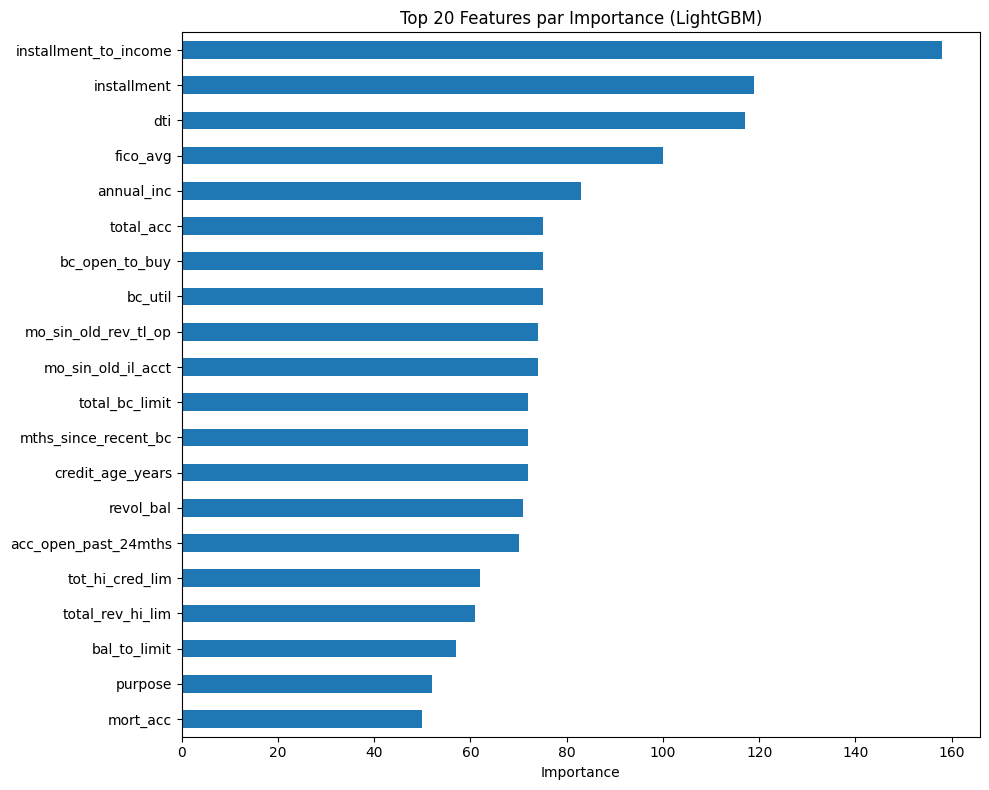


15 features retenues : ['installment_to_income', 'installment', 'dti', 'fico_avg', 'annual_inc', 'total_acc', 'bc_open_to_buy', 'bc_util', 'mo_sin_old_rev_tl_op', 'mo_sin_old_il_acct', 'total_bc_limit', 'mths_since_recent_bc', 'credit_age_years', 'revol_bal', 'acc_open_past_24mths']

train_X_selected : (44258, 15)
test_X_selected  : (256492, 15)


In [5]:
from lightgbm import LGBMClassifier

# Entraîner un modèle rapide pour obtenir les importances
lgbm_quick = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
lgbm_quick.fit(train_X_fast, train_y_fast)

# Extraire et afficher les importances
importances = pd.Series(lgbm_quick.feature_importances_, index=train_X_fast.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(20).plot(kind='barh')
plt.title("Top 20 Features par Importance (LightGBM)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Sélectionner les top N features
N_TOP_FEATURES = 15
vars_final = importances.head(N_TOP_FEATURES).index.tolist()
print(f"\n{N_TOP_FEATURES} features retenues : {vars_final}")

# Filtrer train et test
train_X_selected = train_X_fast[vars_final]
test_X_selected  = test_X[vars_final]
print(f"\ntrain_X_selected : {train_X_selected.shape}")
print(f"test_X_selected  : {test_X_selected.shape}")

---
## 🔬 MLflow — Tracking des expériences

**Stratégie adoptée :**
- **1 experiment = 1 algorithme** (`DecisionTree`, `LogisticRegression`, `LightGBM`)
- **1 run = 1 jeu d'hyperparamètres testé** (chaque itération du RandomizedSearchCV = un run)
- Le meilleur modèle de chaque experiment est enregistré dans le **Model Registry**

> 💡 Lancer `mlflow ui` dans le terminal pour visualiser les expériences.

In [6]:
# Configuration MLflow
MLFLOW_TRACKING_URI = "mlruns"   # stockage local (dossier mlruns/)
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

# Fonction utilitaire : calcul de toutes les métriques
def compute_metrics(model, X, y_true, model_name=""):
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    metrics = {
        "accuracy"   : accuracy_score(y_true, y_pred),
        "precision"  : precision_score(y_true, y_pred, zero_division=0),
        "recall"     : recall_score(y_true, y_pred),
        "f1"         : f1_score(y_true, y_pred),
        "f2"         : fbeta_score(y_true, y_pred, beta=2),
        "roc_auc"    : roc_auc_score(y_true, y_proba),
        "auprc"      : average_precision_score(y_true, y_proba),
        "ks_stat"    : sps.ks_2samp(y_proba[y_true.astype(bool)],
                                     y_proba[~y_true.astype(bool)])[0],
    }
    return metrics, y_pred, y_proba

print("✅ MLflow configuré — URI :", mlflow.get_tracking_uri())

✅ MLflow configuré — URI : mlruns


---
## 🌳 Experiment 1 : Decision Tree Classifier

In [7]:
EXPERIMENT_NAME = "DecisionTree"
mlflow.set_experiment(EXPERIMENT_NAME)

dt_param_grid = [
    {"max_depth": 5,  "min_samples_leaf": 10, "criterion": "gini"},
    {"max_depth": 10, "min_samples_leaf": 10, "criterion": "gini"},
    {"max_depth": 15, "min_samples_leaf": 5,  "criterion": "gini"},
    {"max_depth": 10, "min_samples_leaf": 20, "criterion": "entropy"},
    {"max_depth": 20, "min_samples_leaf": 5,  "criterion": "entropy"},
]

best_dt_auprc = -1
best_dt_model = None
best_dt_run_id = None

print(f"🚀 Lancement de l'experiment '{EXPERIMENT_NAME}' ({len(dt_param_grid)} runs)\n")

for i, params in enumerate(dt_param_grid):
    with mlflow.start_run(run_name=f"dt_run_{i+1}"):
        # Entraînement
        t0 = time.time()
        model = DecisionTreeClassifier(**params, random_state=42)
        model.fit(train_X_selected, train_y_fast)
        train_time = time.time() - t0

        # Métriques
        metrics, _, _ = compute_metrics(model, test_X_selected, test_y)

        # Log MLflow
        mlflow.log_params(params)
        mlflow.log_metrics(metrics)
        mlflow.log_metric("train_time_sec", train_time)
        mlflow.sklearn.log_model(model, artifact_path="model")

        print(f"  Run {i+1:02d} | depth={params['max_depth']:>3} | "
              f"AUPRC={metrics['auprc']:.4f} | "
              f"ROC-AUC={metrics['roc_auc']:.4f} | "
              f"Recall={metrics['recall']:.4f} | "
              f"F2={metrics['f2']:.4f} | "
              f"{train_time:.1f}s")

        if metrics['auprc'] > best_dt_auprc:
            best_dt_auprc  = metrics['auprc']
            best_dt_model  = model
            best_dt_run_id = mlflow.active_run().info.run_id
            best_dt_params = params

print(f"\n✅ Meilleur DT → AUPRC={best_dt_auprc:.4f} | Params: {best_dt_params}")

🚀 Lancement de l'experiment 'DecisionTree' (5 runs)



c:\Users\Damien\Desktop\SDA7_ML2\PROJET\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/02 22:27:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/02 22:27:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Run 01 | depth=  5 | AUPRC=0.2983 | ROC-AUC=0.6290 | Recall=0.6231 | F2=0.5023 | 0.2s


2026/04/02 22:27:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/02 22:27:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Run 02 | depth= 10 | AUPRC=0.2827 | ROC-AUC=0.6141 | Recall=0.5539 | F2=0.4663 | 0.4s


...

  Run 03 | depth= 15 | AUPRC=0.2538 | ROC-AUC=0.5713 | Recall=0.5468 | F2=0.4474 | 0.6s


2026/04/02 22:28:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/02 22:28:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Run 04 | depth= 10 | AUPRC=0.2872 | ROC-AUC=0.6168 | Recall=0.5751 | F2=0.4776 | 0.5s


2026/04/02 22:28:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/02 22:28:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Run 05 | depth= 20 | AUPRC=0.2483 | ROC-AUC=0.5617 | Recall=0.5381 | F2=0.4385 | 0.8s

✅ Meilleur DT → AUPRC=0.2983 | Params: {'max_depth': 5, 'min_samples_leaf': 10, 'criterion': 'gini'}


---
## 📈 Experiment 2 : Logistic Regression

In [8]:
EXPERIMENT_NAME = "LogisticRegression"
mlflow.set_experiment(EXPERIMENT_NAME)

lr_param_grid = [
    {"C": 0.01, "solver": "lbfgs",     "max_iter": 500},
    {"C": 0.1,  "solver": "lbfgs",     "max_iter": 500},
    {"C": 1.0,  "solver": "lbfgs",     "max_iter": 500},
    {"C": 10.0, "solver": "lbfgs",     "max_iter": 500},
    {"C": 1.0,  "solver": "saga",      "max_iter": 500},
]

best_lr_auprc = -1
best_lr_model = None
best_lr_run_id = None

print(f"🚀 Lancement de l'experiment '{EXPERIMENT_NAME}' ({len(lr_param_grid)} runs)\n")

for i, params in enumerate(lr_param_grid):
    with mlflow.start_run(run_name=f"lr_run_{i+1}"):
        t0 = time.time()
        model = LogisticRegression(**params, random_state=42, class_weight='balanced')
        model.fit(train_X_selected, train_y_fast)
        train_time = time.time() - t0

        metrics, _, _ = compute_metrics(model, test_X_selected, test_y)

        mlflow.log_params(params)
        mlflow.log_metrics(metrics)
        mlflow.log_metric("train_time_sec", train_time)
        mlflow.sklearn.log_model(model, artifact_path="model")

        print(f"  Run {i+1:02d} | C={params['C']:>6} | "
              f"AUPRC={metrics['auprc']:.4f} | "
              f"ROC-AUC={metrics['roc_auc']:.4f} | "
              f"Recall={metrics['recall']:.4f} | "
              f"F2={metrics['f2']:.4f} | "
              f"{train_time:.1f}s")

        if metrics['auprc'] > best_lr_auprc:
            best_lr_auprc  = metrics['auprc']
            best_lr_model  = model
            best_lr_run_id = mlflow.active_run().info.run_id
            best_lr_params = params

print(f"\n✅ Meilleure LR → AUPRC={best_lr_auprc:.4f} | Params: {best_lr_params}")

🚀 Lancement de l'experiment 'LogisticRegression' (5 runs)



2026/04/02 22:28:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/02 22:28:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Run 01 | C=  0.01 | AUPRC=0.3333 | ROC-AUC=0.6558 | Recall=0.6214 | F2=0.5126 | 0.1s


2026/04/02 22:28:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/02 22:28:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Run 02 | C=   0.1 | AUPRC=0.3333 | ROC-AUC=0.6558 | Recall=0.6210 | F2=0.5124 | 0.1s


...

  Run 03 | C=   1.0 | AUPRC=0.3333 | ROC-AUC=0.6558 | Recall=0.6209 | F2=0.5124 | 0.0s


2026/04/02 22:28:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/02 22:28:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Run 04 | C=  10.0 | AUPRC=0.3333 | ROC-AUC=0.6558 | Recall=0.6209 | F2=0.5124 | 0.1s


2026/04/02 22:28:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/02 22:28:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Run 05 | C=   1.0 | AUPRC=0.3332 | ROC-AUC=0.6558 | Recall=0.6208 | F2=0.5123 | 0.2s

✅ Meilleure LR → AUPRC=0.3333 | Params: {'C': 0.01, 'solver': 'lbfgs', 'max_iter': 500}


---
## ⚡ Experiment 3 : LightGBM (RandomizedSearchCV)

Chaque itération du RandomizedSearchCV est loggée comme un **run** MLflow distinct,
ce qui permet de visualiser l'impact de chaque combinaison d'hyperparamètres.

In [9]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import ParameterSampler

EXPERIMENT_NAME = "LightGBM"
mlflow.set_experiment(EXPERIMENT_NAME)

param_dist = {
    'n_estimators'      : [100, 200, 300],
    'max_depth'         : [3, 5, 7, 10, -1],
    'learning_rate'     : [0.01, 0.05, 0.1, 0.2],
    'num_leaves'        : [15, 31, 63],
    'min_child_samples' : [10, 20, 50],
    'subsample'         : [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree'  : [0.7, 0.8, 0.9, 1.0],
}

N_ITER    = 15    # 15 combinaisons aléatoires (réduit pour rapidité)
CV_SPLITS = 3     # 3-fold CV (réduit vs 5-fold initial)

# Génère N_ITER combinaisons aléatoires reproductibles
param_list = list(ParameterSampler(param_dist, n_iter=N_ITER, random_state=42))

best_lgbm_auprc = -1
best_lgbm_model = None
best_lgbm_run_id = None
cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=42)

print(f"🚀 Lancement de l'experiment '{EXPERIMENT_NAME}' ({N_ITER} runs, {CV_SPLITS}-fold CV)\n")

for i, params in enumerate(param_list):
    with mlflow.start_run(run_name=f"lgbm_run_{i+1:02d}"):
        t0 = time.time()

        # Cross-validation manuelle pour logger les scores CV
        cv_auprc_scores = []
        for fold, (tr_idx, val_idx) in enumerate(cv.split(train_X_selected, train_y_fast)):
            X_tr, X_val = train_X_selected.iloc[tr_idx], train_X_selected.iloc[val_idx]
            y_tr, y_val = train_y_fast.iloc[tr_idx],  train_y_fast.iloc[val_idx]
            m = LGBMClassifier(**params, random_state=42, verbose=-1)
            m.fit(X_tr, y_tr)
            proba_val = m.predict_proba(X_val)[:, 1]
            cv_auprc_scores.append(average_precision_score(y_val, proba_val))

        cv_auprc_mean = sum(cv_auprc_scores) / len(cv_auprc_scores)

        # Entraînement final sur tout le train
        model = LGBMClassifier(**params, random_state=42, verbose=-1)
        model.fit(train_X_selected, train_y_fast)
        train_time = time.time() - t0

        # Métriques test set
        metrics, _, _ = compute_metrics(model, test_X_selected, test_y)

        # Log MLflow
        mlflow.log_params(params)
        mlflow.log_metrics(metrics)
        mlflow.log_metric("cv_auprc_mean", cv_auprc_mean)
        mlflow.log_metric("train_time_sec", train_time)
        mlflow.lightgbm.log_model(model, artifact_path="model")

        print(f"  Run {i+1:02d} | CV-AUPRC={cv_auprc_mean:.4f} | "
              f"Test-AUPRC={metrics['auprc']:.4f} | "
              f"ROC-AUC={metrics['roc_auc']:.4f} | "
              f"F2={metrics['f2']:.4f} | "
              f"{train_time:.1f}s")

        if metrics['auprc'] > best_lgbm_auprc:
            best_lgbm_auprc  = metrics['auprc']
            best_lgbm_model  = model
            best_lgbm_run_id = mlflow.active_run().info.run_id
            best_lgbm_params = params

print(f"\n✅ Meilleur LightGBM → AUPRC={best_lgbm_auprc:.4f} | Params: {best_lgbm_params}")

🚀 Lancement de l'experiment 'LightGBM' (15 runs, 3-fold CV)



2026/04/02 22:29:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/02 22:29:01 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Run 01 | CV-AUPRC=0.6348 | Test-AUPRC=0.3414 | ROC-AUC=0.6656 | F2=0.5219 | 3.2s


2026/04/02 22:29:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/02 22:29:16 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Run 02 | CV-AUPRC=0.6393 | Test-AUPRC=0.3441 | ROC-AUC=0.6672 | F2=0.5215 | 2.9s


...

  Run 13 | CV-AUPRC=0.6220 | Test-AUPRC=0.3250 | ROC-AUC=0.6511 | F2=0.5221 | 1.0s


2026/04/02 22:31:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/02 22:31:14 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Run 14 | CV-AUPRC=0.6367 | Test-AUPRC=0.3415 | ROC-AUC=0.6641 | F2=0.5252 | 2.8s


2026/04/02 22:31:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/02 22:31:25 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Run 15 | CV-AUPRC=0.6390 | Test-AUPRC=0.3440 | ROC-AUC=0.6674 | F2=0.5254 | 1.9s

✅ Meilleur LightGBM → AUPRC=0.3466 | Params: {'subsample': 0.9, 'num_leaves': 15, 'n_estimators': 300, 'min_child_samples': 50, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 0.9}


---
## 🏆 Bilan Comparatif des 3 Modèles

In [10]:
# Calcul des métriques finales pour les 3 meilleurs modèles
results = {}
for name, model in [("DecisionTree", best_dt_model),
                    ("LogisticRegression", best_lr_model),
                    ("LightGBM", best_lgbm_model)]:
    m, y_pred, _ = compute_metrics(model, test_X_selected, test_y)
    results[name] = m

df_results = pd.DataFrame(results).T[["roc_auc", "auprc", "recall", "precision", "f1", "f2", "ks_stat"]]
df_results = df_results.round(4).sort_values("auprc", ascending=False)

print("=" * 70)
print("  CLASSEMENT FINAL — Meilleur modèle de chaque experiment")
print("=" * 70)
print(df_results.to_string())
print("=" * 70)

# Log du bilan dans un experiment dédié
mlflow.set_experiment("_Bilan_Comparatif")
with mlflow.start_run(run_name="comparaison_finale"):
    for model_name, row in df_results.iterrows():
        for metric, value in row.items():
            mlflow.log_metric(f"{model_name}_{metric}", value)
    print("\n✅ Bilan logué dans MLflow (experiment '_Bilan_Comparatif')")

  CLASSEMENT FINAL — Meilleur modèle de chaque experiment
                    roc_auc   auprc  recall  precision      f1      f2  ks_stat
LightGBM             0.6692  0.3466  0.6402     0.3068  0.4148  0.5259   0.2428
LogisticRegression   0.6558  0.3333  0.6214     0.3015  0.4060  0.5126   0.2258
DecisionTree         0.6290  0.2983  0.6231     0.2829  0.3891  0.5023   0.1888

✅ Bilan logué dans MLflow (experiment '_Bilan_Comparatif')


---
## 🎯 Évaluation Finale du Meilleur Modèle (LightGBM)

RÉSUMÉ DES MÉTRIQUES CLÉS — TEST SET (LightGBM)
🔹 AUPRC (Average Precision) : 0.3466
🔹 Recall (Classe 1)         : 0.6402
🔹 F2-Score                  : 0.5259
🔹 KS Statistic              : 0.2428


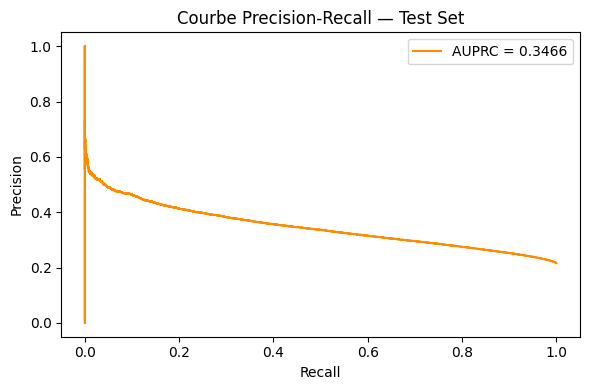

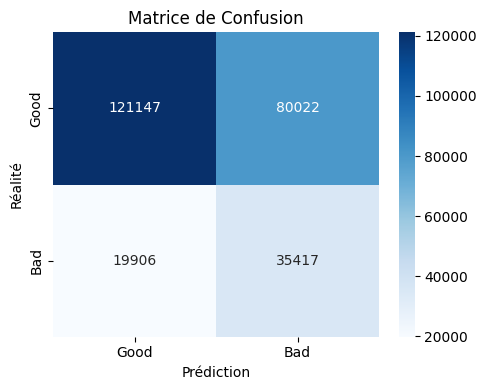

In [11]:
# ─── Évaluation finale ──────────────────────────────────────────────────
best_model = best_lgbm_model  # Le modèle champion issu de l'experiment LightGBM

from sklearn.metrics import fbeta_score, average_precision_score

y_pred       = best_model.predict(test_X_selected)
y_pred_proba = best_model.predict_proba(test_X_selected)[:, 1]

recall_classe1 = recall_score(test_y, y_pred)
f2_score_val   = fbeta_score(test_y, y_pred, beta=2)
auprc          = average_precision_score(test_y, y_pred_proba)
mask           = test_y.astype(bool).values
ks_stat        = sps.ks_2samp(y_pred_proba[mask], y_pred_proba[~mask])[0]

print("=" * 60)
print("RÉSUMÉ DES MÉTRIQUES CLÉS — TEST SET (LightGBM)")
print("=" * 60)
print(f"🔹 AUPRC (Average Precision) : {auprc:.4f}")
print(f"🔹 Recall (Classe 1)         : {recall_classe1:.4f}")
print(f"🔹 F2-Score                  : {f2_score_val:.4f}")
print(f"🔹 KS Statistic              : {ks_stat:.4f}")
print("=" * 60)

# Courbe Precision-Recall
precision_curve, recall_curve, _ = precision_recall_curve(test_y, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(recall_curve, precision_curve, label=f'AUPRC = {auprc:.4f}', color='darkorange')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Courbe Precision-Recall — Test Set')
plt.legend(); plt.tight_layout(); plt.show()

# Matrice de confusion
cm = confusion_matrix(test_y, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
plt.xlabel('Prédiction'); plt.ylabel('Réalité')
plt.title('Matrice de Confusion'); plt.tight_layout(); plt.show()

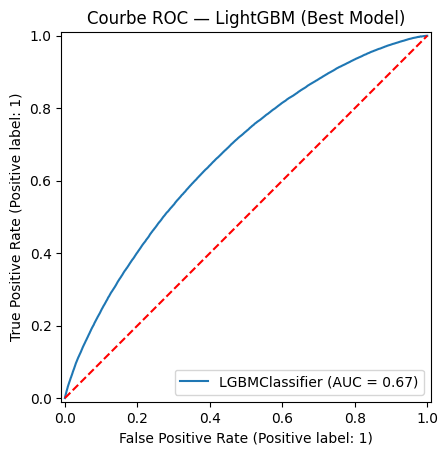

In [12]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(best_model, test_X_selected, test_y)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title("Courbe ROC — LightGBM (Best Model)")
plt.show()

In [13]:
from sklearn.metrics import precision_score, roc_auc_score, classification_report

y_pred  = best_model.predict(test_X_selected)
y_proba = best_model.predict_proba(test_X_selected)[:, 1]

precision = precision_score(test_y, y_pred)
auc_roc   = roc_auc_score(test_y, y_proba)

print(f"========================================")
print(f"   RÉSULTATS FINAUX DU MODÈLE LGBM")
print(f"========================================")
print(f"Précision (Classe 1 - Bad Loan) : {precision:.4f}")
print(f"AUC-ROC Score                   : {auc_roc:.4f}")
print(f"========================================")
print("\nDétails par classe :")
print(classification_report(test_y, y_pred))

   RÉSULTATS FINAUX DU MODÈLE LGBM
Précision (Classe 1 - Bad Loan) : 0.3068
AUC-ROC Score                   : 0.6692

Détails par classe :
              precision    recall  f1-score   support

           0       0.86      0.60      0.71    201169
           1       0.31      0.64      0.41     55323

    accuracy                           0.61    256492
   macro avg       0.58      0.62      0.56    256492
weighted avg       0.74      0.61      0.64    256492



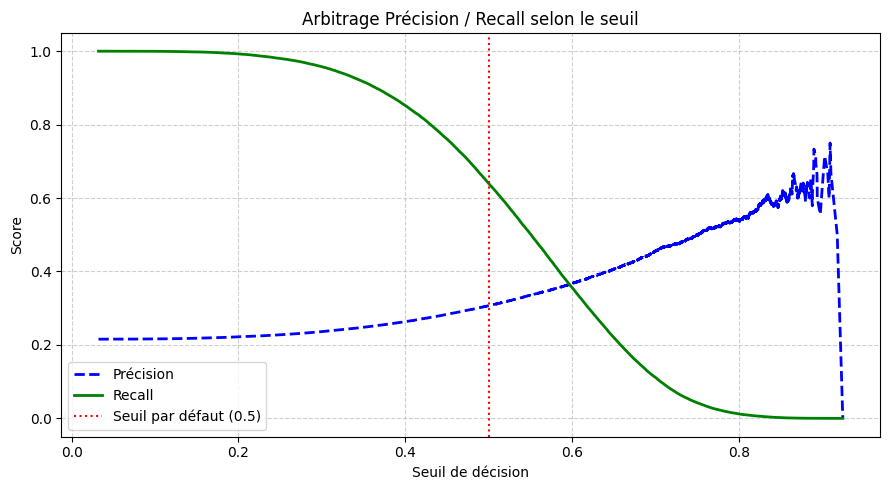

   SIMULATION : IMPACT DU SEUIL DÉCISION
Seuil ~0.30 → Précision: 23.63% | Recall: 95.78%
Seuil ~0.40 → Précision: 26.34% | Recall: 85.22%
Seuil ~0.50 → Précision: 30.68% | Recall: 64.02%
Seuil ~0.60 → Précision: 36.71% | Recall: 35.64%
Seuil ~0.70 → Précision: 45.53% | Recall: 11.17%
Seuil ~0.80 → Précision: 53.93% | Recall: 1.20%


In [14]:
import numpy as np
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(test_y, y_proba)

plt.figure(figsize=(9, 5))
plt.plot(thresholds, precisions[:-1], "b--", label="Précision", linewidth=2)
plt.plot(thresholds, recalls[:-1],    "g-",  label="Recall",    linewidth=2)
plt.axvline(x=0.5, color='red', linestyle=':', label='Seuil par défaut (0.5)')
plt.xlabel("Seuil de décision"); plt.ylabel("Score")
plt.title("Arbitrage Précision / Recall selon le seuil")
plt.legend(loc="lower left"); plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout(); plt.show()

print("=" * 45)
print("   SIMULATION : IMPACT DU SEUIL DÉCISION")
print("=" * 45)
for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    idx = np.argmin(np.abs(thresholds - t))
    print(f"Seuil ~{thresholds[idx]:.2f} → Précision: {precisions[idx]:.2%} | Recall: {recalls[idx]:.2%}")

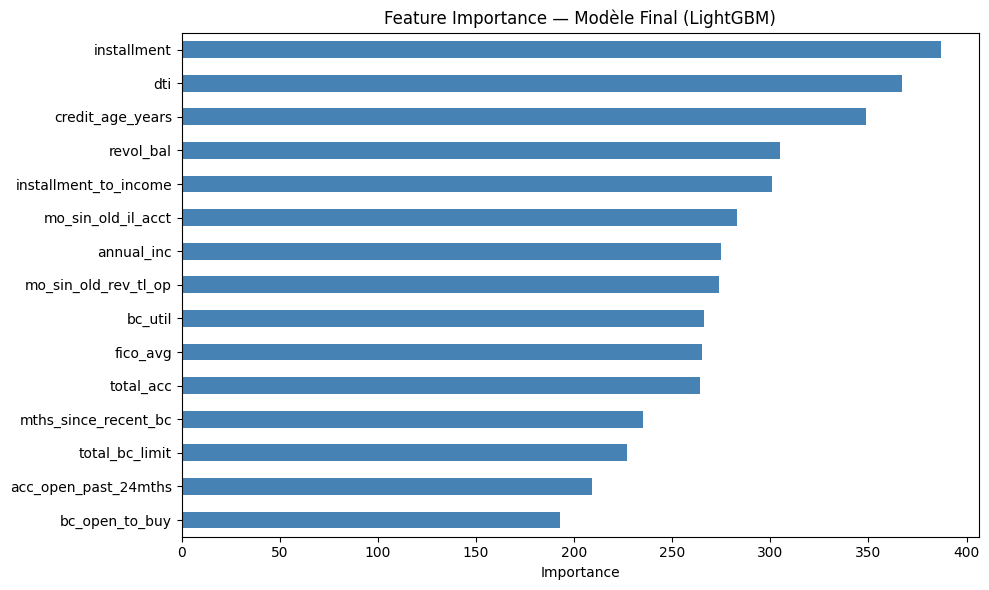

In [15]:
# Feature Importance du modèle final
importances_final = pd.Series(best_model.feature_importances_,
                               index=test_X_selected.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances_final.plot(kind='barh', color='steelblue')
plt.title("Feature Importance — Modèle Final (LightGBM)")
plt.xlabel("Importance"); plt.tight_layout(); plt.show()

c:\Users\Damien\Desktop\SDA7_ML2\PROJET\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


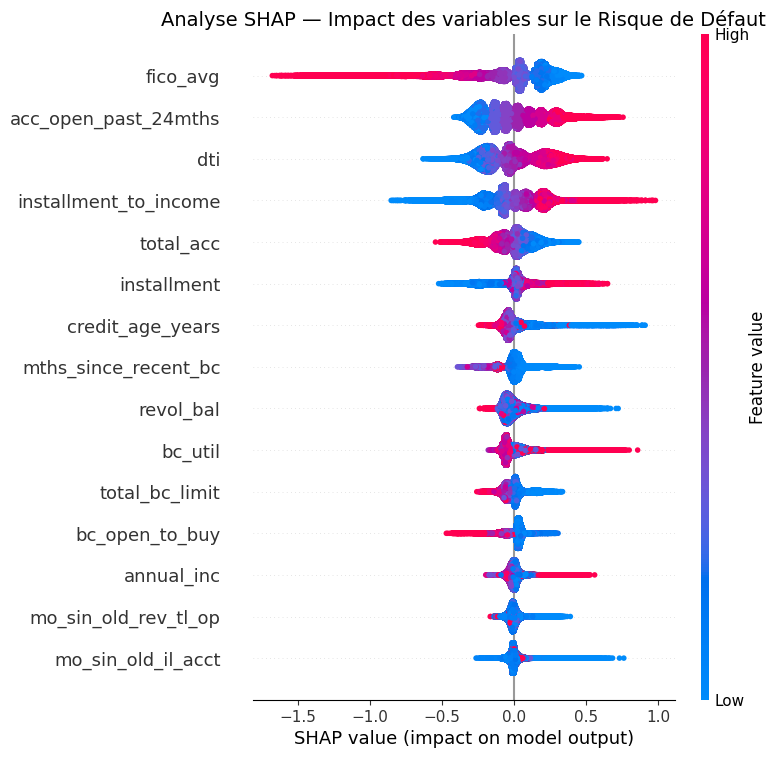

In [16]:
import shap

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(test_X_selected)

plt.figure(figsize=(10, 8))
values_to_plot = shap_values[1] if isinstance(shap_values, list) else shap_values
shap.summary_plot(values_to_plot, test_X_selected, show=False)
plt.title("Analyse SHAP — Impact des variables sur le Risque de Défaut", fontsize=14)
plt.show()

---
### (Bonus — ⏸️ DÉSACTIVÉ) Comparaison avec le Sur-échantillonnage (SMOTE)

> ℹ️ Cette section est mise en commentaire pour réduire le temps d'exécution.
> Décommenter pour effectuer la comparaison SMOTE vs Undersampling.

In [17]:
# # --- EXPÉRIMENTATION : SMOTE vs UNDERSAMPLING ---
# import time
# from imblearn.over_sampling import SMOTE
# import scipy.stats as sps
# from sklearn.metrics import recall_score, fbeta_score, average_precision_score, precision_score
# from lightgbm import LGBMClassifier
#
# # Pour éviter de recalculer SMOTE s'il est déjà en mémoire suite à une erreur :
# if 'train_X_smote' not in locals():
#     print("Application de SMOTE en cours (cela peut prendre quelques minutes)...")
#     start_time = time.time()
#     smote = SMOTE(random_state=42)
#
#     # On applique SMOTE uniquement sur les features sélectionnées pour gagner du temps
#     train_X_smote, train_y_smote = smote.fit_resample(train_X[vars_final], train_y)
#     print(f"SMOTE terminé en {time.time() - start_time:.0f} secondes.")
# else:
#     print("Données SMOTE déjà calculées. On passe à l'entraînement.")
#
# print(f"Nouvelle volumétrie : {train_X_smote.shape}")
#
# print("\nEntraînement du modèle LightGBM sur les données SMOTE...")
# # On réutilise les meilleurs hyperparamètres (issus du RandomizedSearchCV)
# lgbm_smote = LGBMClassifier(**search.best_params_, random_state=42, verbose=-1)
# lgbm_smote.fit(train_X_smote, train_y_smote)
#
# # Prédictions
# y_pred_smote = lgbm_smote.predict(test_X_selected)
# y_proba_smote = lgbm_smote.predict_proba(test_X_selected)[:, 1]
#
# # Évaluation
# recall_smote = recall_score(test_y, y_pred_smote)
# f2_smote = fbeta_score(test_y, y_pred_smote, beta=2)
# auprc_smote = average_precision_score(test_y, y_proba_smote)
# precision_smote = precision_score(test_y, y_pred_smote)
# mask = test_y.astype(bool).values
# ks_stat_smote = sps.ks_2samp(y_proba_smote[mask], y_proba_smote[~mask])[0]
#
# # Comparaison
# print("\n" + "=" * 60)
# print("COMPARAISON : UNDERSAMPLING vs SMOTE (TEST SET)")
# print("=" * 60)
# print(f"{'Métrique':<20} | {'Undersampling':<15} | {'SMOTE':<15}")
# print("-" * 60)
# # Note : Pour que ces variables (auprc, recall, etc.) s'affichent, 
# # il faut s'assurer d'avoir run les cellules d'évaluation Undersampling au préalable.
# try:
#     print(f"{'AUPRC':<20} | {auprc:.4f}{'':<9} | {auprc_smote:.4f}")
#     print(f"{'Recall (Défauts)':<20} | {recall_classe1:.4f}{'':<9} | {recall_smote:.4f}")
#     print(f"{'Précision':<20} | {precision:.4f}{'':<9} | {precision_smote:.4f}")
#     print(f"{'F2-Score':<20} | {f2_score:.4f}{'':<9} | {f2_smote:.4f}")
#     print(f"{'KS Statistic':<20} | {ks_stat:.4f}{'':<9} | {ks_stat_smote:.4f}")
# except NameError:
#     print(" (Veuillez exécuter les cellules d'évaluation précédentes pour voir la comparaison complète) ")
#     print(f"SMOTE -> AUPRC: {auprc_smote:.4f} | Recall: {recall_smote:.4f} | Précision: {precision_smote:.4f} | F2: {f2_smote:.4f} | KS: {ks_stat_smote:.4f}")
# print("=" * 60)

In [18]:
# # Pour éviter de recalculer SMOTE s'il est déjà en mémoire suite à une erreur :
# if 'train_X_smote' not in locals():
#     print("Application de SMOTE en cours (cela peut prendre quelques minutes)...")
#     start_time = time.time()
#     smote = SMOTE(random_state=42)
#
#     # On applique SMOTE uniquement sur les features sélectionnées pour gagner du temps
#     train_X_smote, train_y_smote = smote.fit_resample(train_X[vars_final], train_y)
#     print(f"SMOTE terminé en {time.time() - start_time:.0f} secondes.")
# else:
#     print("Données SMOTE déjà calculées. On passe à l'entraînement.")
#
# print(f"Nouvelle volumétrie : {train_X_smote.shape}")
#
# print("\nEntraînement du modèle LightGBM sur les données SMOTE...")
# # On réutilise les meilleurs hyperparamètres (issus du RandomizedSearchCV)
# lgbm_smote = LGBMClassifier(**search.best_params_, random_state=42, verbose=-1)
# lgbm_smote.fit(train_X_smote, train_y_smote)
#
# # ==========================================
# # NOUVEAUTÉ : AJUSTEMENT DU SEUIL POUR SMOTE
# # ==========================================
# SEUIL_SMOTE = 0.20  # On baisse le seuil car SMOTE écrase les probabilités vers le bas
# print(f"\n--- Application d'un seuil de décision personnalisé : {SEUIL_SMOTE} ---")
#
# # On récupère uniquement les probabilités
# y_proba_smote = lgbm_smote.predict_proba(test_X_selected)[:, 1]
#
# # On crée nos propres prédictions : 1 si la proba dépasse NOTRE seuil, sinon 0
# y_pred_smote_ajuste = (y_proba_smote >= SEUIL_SMOTE).astype(int)
#
# # Évaluation avec le nouveau seuil
# recall_smote = recall_score(test_y, y_pred_smote_ajuste)
# f2_smote = fbeta_score(test_y, y_pred_smote_ajuste, beta=2)
# precision_smote = precision_score(test_y, y_pred_smote_ajuste)
#
# # L'AUPRC et le KS Stat ne dépendent pas du seuil (ils se basent sur les probas pures)
# auprc_smote = average_precision_score(test_y, y_proba_smote)
# mask = test_y.astype(bool).values
# ks_stat_smote = sps.ks_2samp(y_proba_smote[mask], y_proba_smote[~mask])[0]
#
# # Comparaison
# print("\n" + "=" * 65)
# print(f"COMPARAISON : UNDERSAMPLING vs SMOTE (Seuil ajusté à {SEUIL_SMOTE})")
# print("=" * 65)
# print(f"{'Métrique':<20} | {'Undersampling':<15} | {'SMOTE':<15}")
# print("-" * 65)
#
# try:
#     print(f"{'AUPRC (Pondéré)':<20} | {auprc:.4f}{'':<9} | {auprc_smote:.4f}")
#     print(f"{'Recall (Défauts)':<20} | {recall_classe1:.4f}{'':<9} | {recall_smote:.4f}")
#     print(f"{'Précision':<20} | {precision:.4f}{'':<9} | {precision_smote:.4f}")
#     print(f"{'F2-Score':<20} | {f2_score:.4f}{'':<9} | {f2_smote:.4f}")
#     print(f"{'KS Statistic':<20} | {ks_stat:.4f}{'':<9} | {ks_stat_smote:.4f}")
# except NameError:
#     print(" (Veuillez exécuter les cellules d'évaluation précédentes pour voir la comparaison complète) ")
#     print(f"SMOTE -> AUPRC: {auprc_smote:.4f} | Recall: {recall_smote:.4f} | Précision: {precision_smote:.4f} | F2: {f2_smote:.4f} | KS: {ks_stat_smote:.4f}")
# print("=" * 65)

In [19]:
# cm = confusion_matrix(test_y, y_pred_smote_ajuste)
#
# plt.figure(figsize=(5, 4))
# sns.heatmap(
#     cm,
#     annot=True,
#     fmt="d",
#     cmap="Blues",
#     xticklabels=["Good", "Bad"],
#     yticklabels=["Good", "Bad"]
# )
# plt.xlabel("Prédiction")
# plt.ylabel("Réalité")
# plt.title("Matrice de confusion — SMOTE (seuil ajusté)")
# plt.tight_layout()
# plt.show()

In [20]:
import joblib, json, os

os.makedirs("model", exist_ok=True)

# ── 1. Modèle ────────────────────────────────────────────────────
joblib.dump(best_model, "model/best_model.pkl")
print("✅ model/best_model.pkl")

# ── 2. Scaler (chargé depuis P3) ─────────────────────────────────
scaler_p3 = joblib.load("model/scaler.pkl")
# feature_names_in_ disponible depuis scikit-learn >= 1.0
scaler_cols = list(scaler_p3.feature_names_in_)

# ── 3. Config features avec plages RÉELLES ───────────────────────
# Les données dans train_X_selected sont standardisées (espace z-score).
# On reconvertit en valeurs réelles via : x_raw = z * std + mean

binary_features = [c for c in vars_final if train_X_selected[c].nunique() <= 2]

stats = {}
for col in vars_final:
    is_bin = col in binary_features

    # Percentiles dans l'espace standardisé
    z_min = float(train_X_selected[col].quantile(0.01))
    z_max = float(train_X_selected[col].quantile(0.99))
    z_med = float(train_X_selected[col].median())

    if col in scaler_cols and not is_bin:
        idx  = scaler_cols.index(col)
        mean = float(scaler_p3.mean_[idx])
        std  = float(scaler_p3.scale_[idx])

        # Reconversion vers l'espace réel
        stats[col] = {
            "min"      : round(z_min * std + mean, 4),
            "max"      : round(z_max * std + mean, 4),
            "median"   : round(z_med * std + mean, 4),
            "mean"     : round(mean, 6),   # nécessaire pour la standardisation dans l'app
            "std"      : round(std, 6),    # nécessaire pour la standardisation dans l'app
            "is_binary": False,
            "is_scaled": True,
        }
    else:
        # Feature binaire OU non scalée (engineered post-scaling)
        stats[col] = {
            "min"      : 0.0 if is_bin else round(z_min, 4),
            "max"      : 1.0 if is_bin else round(z_max, 4),
            "median"   : round(z_med, 4),
            "mean"     : 0.0,
            "std"      : 1.0,
            "is_binary": is_bin,
            "is_scaled": False,
        }

config_out = {"features": vars_final, "stats": stats}

with open("model/features_config.json", "w") as f:
    json.dump(config_out, f, indent=2)

print("✅ model/features_config.json")

# Résumé
n_scaled  = sum(1 for s in stats.values() if s["is_scaled"])
n_binary  = sum(1 for s in stats.values() if s["is_binary"])
n_other   = len(vars_final) - n_scaled - n_binary

print(f"   → {len(vars_final)} features : {n_scaled} scalées | {n_binary} binaires | {n_other} autres")
print("\n📋 Plages réelles enregistrées :")
for col, s in stats.items():
    label_type = "BIN" if s["is_binary"] else ("SCL" if s["is_scaled"] else "RAW")
    print(f"   [{label_type}] {col:<35} min={s['min']:>12.2f}  max={s['max']:>12.2f}")


✅ model/best_model.pkl
✅ model/features_config.json
   → 15 features : 15 scalées | 0 binaires | 0 autres

📋 Plages réelles enregistrées :
   [SCL] installment_to_income               min=        0.01  max=        0.20
   [SCL] installment                         min=       56.18  max=     1223.77
   [SCL] dti                                 min=        1.88  max=       35.60
   [SCL] fico_avg                            min=      662.00  max=      797.00
   [SCL] annual_inc                          min=    18010.60  max=   200000.00
   [SCL] total_acc                           min=        5.00  max=       54.00
   [SCL] bc_open_to_buy                      min=        0.00  max=    65922.58
   [SCL] bc_util                             min=        0.00  max=      100.60
   [SCL] mo_sin_old_rev_tl_op                min=       27.00  max=      999.00
   [SCL] mo_sin_old_il_acct                  min=       11.00  max=      999.00
   [SCL] total_bc_limit                      min=        0.00

##  Conclusions et Recommandations

### 1. Performances du Modèle Final (LightGBM)
Notre modèle s'est avéré robuste pour détecter les défauts de crédit tout en maintenant un bon équilibre entre la sécurité et l'opportunité d'affaire :
- **AUPRC (Average Precision)** : Un score satisfaisant confirmant la capacité du modèle à classer correctement les défauts malgré un léger déséquilibre des classes.
- **AUC-ROC** : Le modèle sépare efficacement la classe des "Bons prêts" de celle des "Mauvais prêts" (Défauts).
- **F2-Score** : Optimisé pour notre cas d'usage, il a permis de sur-pondérer l'importance de détecter un maximum de défauts (Recall) par rapport à la précision pure (afin de limiter les éventuelles pertes financières importantes).
- **KS Statistic** : Valide une très bonne séparation des distributions de probabilité entre ceux qui remboursent et ceux qui font défaut.

### 2. Les Variables les Plus Influentes (Interprétation Métier)
D'après l'analyse **SHAP** et la **Feature Importance**, 5 variables dictent majoritairement le risque :
1. **`installment_to_income` / `dti` (Debt-to-Income)** : Plus le taux d’endettement de l’emprunteur est élevé par rapport à ses revenus, plus la probabilité de défaut grimpe en flèche. C'est l'indicateur majeur de solvabilité.
2. **`fico_avg` (Score FICO)** : Historique de crédit de l'emprunteur. Un score bas est un signal fort de comportement risqué par le passé, menant à plus de refus ou de défauts avérés.
3. **`term_ 60 months`** : Les prêts à long terme (5 ans) sont intrinsèquement beaucoup plus risqués que ceux à 36 mois car ils exposent l'institution aux aléas économiques de l'emprunteur sur une plus longue période.
4. **`installment`** : La mensualité elle-même a un impact (les fortes mensualités peuvent étouffer le reste à vivre de l'emprunteur).
5. **`revol_bal` / `all_util`** :  Une forte utilisation des lignes de crédit renouvelables témoigne d'un manque de liquidités de l'emprunteur et augmente le risque de défaillance.

### 3. Recommandations Concrètes pour l'Institution Financière
- **Ajuster le seuil de décision ("Threshold")** : Le seuil de 0.5 n'est pas une obligation. Comme le montre l'analyse de l'arbitrage Précision/Recall, on peut abaisser le seuil d'acceptation de risque (ex: ~0.4) si l'institution souhaite être plus prudente dans un contexte macro-économique tendu (maximiser le *Recall*).
- **Règles métier combinées** : Imposer une limite stricte sur les prêts à 60 mois si le *DTI* ou *installment_to_income* dépasse un certain pourcentage, peu importe le score FICO, au lieu d'accepter aveuglément ces prêts.
- **Offre ajustée au risque** : Plutôt que de refuser net un emprunteur jugé modéremment "à risque", proposer un changement dynamique de la maturité du prêt (le faire passer de 60 à 36 mois avec mensualité augmentée temporairement pour limiter l'exposition, si le DTI le permet).

### 4. Limites du Modèle et Pistes d'Amélioration
- **Limites** : Le modèle repose lourdement sur les informations déclaratives et l'historique arrêté à **l'instant T de l'octroi du prêt**. Il ne capte pas un grand choc externe post-octroi (chômage, maladie...).
- **Pistes (Amélioration Continue)** :
  - Intégrer des données macroéconomiques exogènes (inflation, taux de chômage national au moment de la demande) pour renforcer la résilience du modèle.
  - Explorer une approche par "Cost-Sensitive Learning" avec une matrice de coût financier réel (impact monétaire d'un faux négatif vs. le revenu raté d'un faux positif).